## 1. Loading Data Set
Loading all 9 Olist CSV files into pandas DataFrames and performing initial sanity checks on shape and missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = os.path.expanduser("~/Desktop/Projects/ApexPlanet/Task 2/data/")

orders = pd.read_csv(data_path + "olist_orders_dataset.csv")
order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv")
order_payments = pd.read_csv(data_path + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(data_path + "olist_customers_dataset.csv")
sellers = pd.read_csv(data_path + "olist_sellers_dataset.csv")
products = pd.read_csv(data_path + "olist_products_dataset.csv")
geolocation = pd.read_csv(data_path + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(data_path + "product_category_name_translation.csv")

datasets = {
    "orders" : orders, "order_items" : order_items,
    "order_payments" : order_payments, "order_reviews" : order_reviews, "customers" : customers, "sellers" : sellers, "products" : products, "geolocation" : geolocation, "category_translation" : category_translation
}

for name, df in datasets.items():
    print(f"{name} : {df.shape[0]} rows, {df.shape[1]} cols")


orders : 99441 rows, 8 cols
order_items : 112650 rows, 7 cols
order_payments : 103886 rows, 5 cols
order_reviews : 99224 rows, 7 cols
customers : 99441 rows, 5 cols
sellers : 3095 rows, 4 cols
products : 32951 rows, 9 cols
geolocation : 1000163 rows, 5 cols
category_translation : 71 rows, 2 cols


In [2]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

products = products.merge(category_translation, on="product_category_name", how="left")
products = products.loc[:,~products.columns.duplicated()]

master = orders.merge(order_items, on="order_id", how="left") \
               .merge(order_payments, on="order_id", how="left") \
               .merge(order_reviews[["order_id", "review_score"]], on="order_id", how="left") \
               .merge(customers, on="customer_id", how="left") \
               .merge(products, on="product_id", how="left") \
               .merge(sellers, on="seller_id", how="left")

print(f"Master dataframe: {master.shape[0]} rows, {master.shape[1]} cols")
print(f"\nOrder status breakdown:")
print(orders["order_status"].value_counts())

Master dataframe: 119143 rows, 38 cols

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 2. Descriptive Statistics & Univariate Analysis
Calculating summary statistics for key numerical columns and visualizing distributions for price, review scores, product categories, customer states, and payment types.

In [3]:
for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"{name.upper()}")
    print(f"{'='*40}")
    print(df.dtypes)
    print(f"\nMissing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])



ORDERS
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
order_year                                int32
order_month                               int32
order_year_month                      period[M]
dtype: object

Missing values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Missing values:
Series([], dtype: int64)

ORDER_PAYMENTS
orde

In [7]:
print("=== NUMERICAL SUMMARY ===")
numerical_cols = ["price","freight_value", "payment_value","product_weight_g","review_score"]
print(master[numerical_cols].describe().round(2))

print("\n=== CATEGORICAL SUMMARY ===")
cat_cols = ["order_status", "customer_state", "payment_type", "product_category_name_english"]
for col in cat_cols:
    print(f"\nTop 5 - {col}:")
    print(master[col].value_counts().head())

=== NUMERICAL SUMMARY ===
           price  freight_value  payment_value  product_weight_g  review_score
count  118310.00      118310.00      119140.00         118290.00     118146.00
mean      120.65          20.03         172.74           2112.25          4.02
std       184.11          15.84         267.78           3786.70          1.40
min         0.85           0.00           0.00              0.00          1.00
25%        39.90          13.08          60.85            300.00          4.00
50%        74.90          16.28         108.16            700.00          5.00
75%       134.90          21.18         189.24           1800.00          5.00
max      6735.00         409.68       13664.08          40425.00          5.00

=== CATEGORICAL SUMMARY ===

Top 5 - order_status:
order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
Name: count, dtype: int64

Top 5 - customer_state:
customer_state
SP    50265
RJ    1551

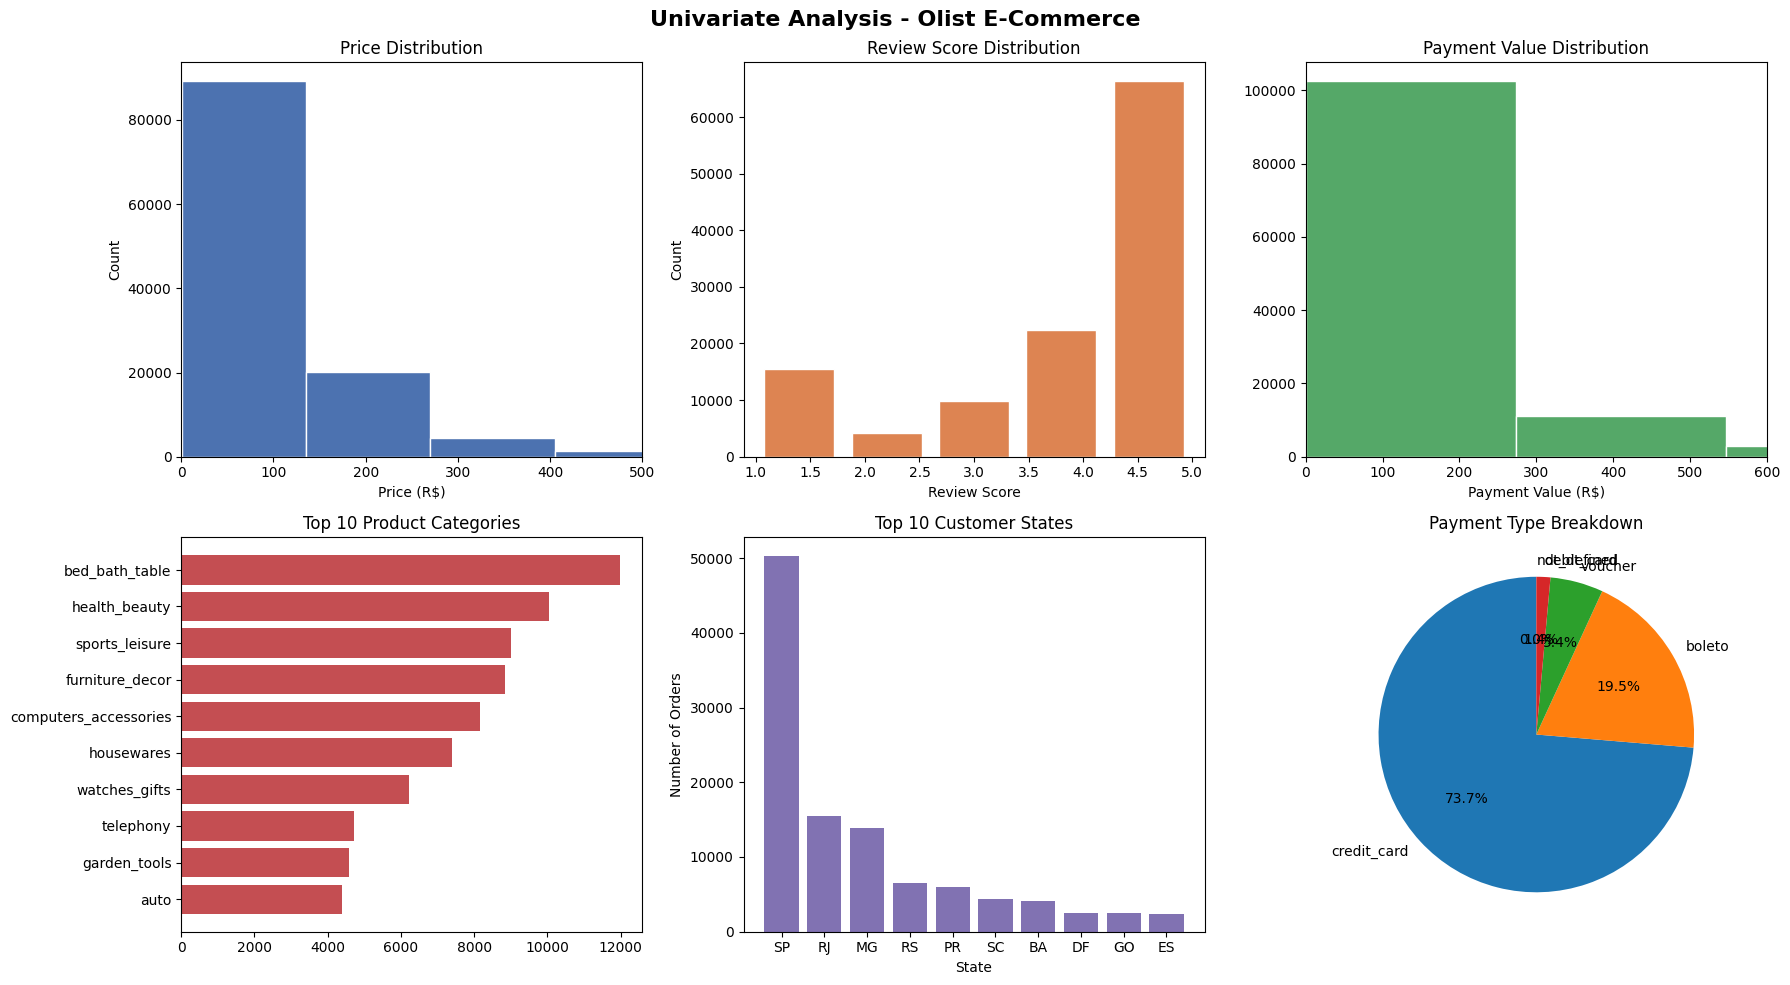

Saved!


In [12]:
fig, axes = plt.subplots(2,3, figsize=(18,10))
fig.suptitle("Univariate Analysis - Olist E-Commerce", fontsize=16, fontweight="bold")

# 1. Price Distribution
axes[0,0].hist(master["price"].dropna(),bins=50,color="#4C72B0",edgecolor="white")
axes[0,0].set_title("Price Distribution")
axes[0,0].set_xlabel("Price (R$)")
axes[0,0].set_ylabel("Count")
axes[0,0].set_xlim(0,500)

# 2. Review score distribution
axes[0,1].hist(master["review_score"].dropna(), bins=5,color="#DD8452",edgecolor="white",rwidth=0.8)
axes[0,1].set_title("Review Score Distribution")
axes[0,1].set_xlabel("Review Score")
axes[0,1].set_ylabel("Count")

# 3. Payment value distribution
axes[0,2].hist(master["payment_value"].dropna(),bins=50,color="#55A868",edgecolor="white")
axes[0,2].set_title("Payment Value Distribution")
axes[0,2].set_xlabel("Payment Value (R$)")
axes[0,2].set_xlim(0,600)

# 4. Top 10 product categories
top_cats = master["product_category_name_english"].value_counts().head(10)
axes[1,0].barh(top_cats.index,top_cats.values, color="#C44E52")
axes[1,0].set_title("Top 10 Product Categories")
axes[1,0].invert_yaxis()

# 5. Orders by customers state
top_states = master["customer_state"].value_counts().head(10)
axes[1,1].bar(top_states.index, top_states.values, color="#8172B2")
axes[1,1].set_title("Top 10 Customer States")
axes[1,1].set_xlabel("State")
axes[1,1].set_ylabel("Number of Orders")

# 6. Payment type breakdown
pay_types = master["payment_type"].value_counts()
axes[1,2].pie(pay_types.values, labels=pay_types.index, autopct="%1.1f%%", startangle=90)
axes[1,2].set_title("Payment Type Breakdown")

plt.tight_layout()
plt.savefig("../outputs/01_univariate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 3. SQL Business Questions
Loading data into an in-memory SQLite database and writing SQL queries to answer 7 key business questions covering revenue, trends, delivery performance, and customer behaviour.

In [13]:
import sqlite3

orders["order_year_month"] = orders["order_year_month"].astype(str)

conn = sqlite3.connect(":memory:")
orders.to_sql("orders", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
order_payments.to_sql("order_payments", conn, index=False, if_exists="replace")
order_reviews.to_sql("order_reviews", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")
sellers.to_sql("sellers", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")

print("All tables loaded into SQLite!")
print("\nTables available:")
print(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn))

All tables loaded into SQLite!

Tables available:
             name
0          orders
1     order_items
2  order_payments
3   order_reviews
4       customers
5         sellers
6        products


In [14]:
q1 = pd.read_sql_query("""
    SELECT 
        p.product_category_name,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        COUNT(DISTINCT oi.order_id) AS total_orders
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name IS NOT NULL
    GROUP BY p.product_category_name
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

print("Q1: Top 10 Categories by Revenue")
print(q1)

Q1: Top 10 Categories by Revenue
    product_category_name  total_revenue  total_orders
0            beleza_saude     1258681.34          8836
1      relogios_presentes     1205005.68          5624
2         cama_mesa_banho     1036988.68          9417
3           esporte_lazer      988048.97          7720
4  informatica_acessorios      911954.32          6689
5        moveis_decoracao      729762.49          6449
6              cool_stuff      635290.85          3632
7   utilidades_domesticas      632248.66          5884
8              automotivo      592720.11          3897
9      ferramentas_jardim      485256.46          3518


In [15]:
# Business Question 2: Monthly order trend
q2 = pd.read_sql_query("""
    SELECT 
        order_year_month,
        COUNT(DISTINCT order_id) AS total_orders,
        ROUND(AVG(strftime('%s', order_delivered_customer_date) - 
              strftime('%s', order_purchase_timestamp)) / 86400.0, 1) AS avg_delivery_days
    FROM orders
    WHERE order_status = 'delivered'
    GROUP BY order_year_month
    ORDER BY order_year_month
""", conn)

print("Q2: Monthly Order Trend")
print(q2)

# Business Question 3: Top 5 states by revenue
q3 = pd.read_sql_query("""
    SELECT 
        c.customer_state,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_state
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)

print("\nQ3: Top 5 States by Revenue")
print(q3)

# Business Question 4: Average review score by product category
q4 = pd.read_sql_query("""
    SELECT 
        p.product_category_name,
        ROUND(AVG(r.review_score), 2) AS avg_review_score,
        COUNT(r.review_id) AS total_reviews
    FROM order_reviews r
    JOIN order_items oi ON r.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name IS NOT NULL
    GROUP BY p.product_category_name
    ORDER BY avg_review_score DESC
    LIMIT 10
""", conn)

print("\nQ4: Top 10 Categories by Review Score")
print(q4)

# Business Question 5: Payment method vs average order value
q5 = pd.read_sql_query("""
    SELECT 
        payment_type,
        COUNT(*) AS total_transactions,
        ROUND(AVG(payment_value), 2) AS avg_payment_value,
        ROUND(SUM(payment_value), 2) AS total_revenue
    FROM order_payments
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""", conn)

print("\nQ5: Payment Method Analysis")
print(q5)

# Business Question 6: Top 10 sellers by revenue
q6 = pd.read_sql_query("""
    SELECT 
        oi.seller_id,
        s.seller_city,
        s.seller_state,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        COUNT(DISTINCT oi.order_id) AS total_orders
    FROM order_items oi
    JOIN sellers s ON oi.seller_id = s.seller_id
    GROUP BY oi.seller_id
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

print("\nQ6: Top 10 Sellers by Revenue")
print(q6)

# Business Question 7: Late delivery analysis by state
q7 = pd.read_sql_query("""
    SELECT 
        c.customer_state,
        COUNT(*) AS total_orders,
        SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN 1 ELSE 0 END) AS late_deliveries,
        ROUND(100.0 * SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN 1 ELSE 0 END) / COUNT(*), 1) AS late_pct
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE order_status = 'delivered'
    GROUP BY c.customer_state
    ORDER BY late_pct DESC
    LIMIT 10
""", conn)

print("\nQ7: Late Delivery Rate by State")
print(q7)

Q2: Monthly Order Trend
   order_year_month  total_orders  avg_delivery_days
0           2016-09             1               54.8
1           2016-10           265               19.6
2           2016-12             1                4.7
3           2017-01           750               12.6
4           2017-02          1653               13.2
5           2017-03          2546               13.0
6           2017-04          2303               14.9
7           2017-05          3546               11.3
8           2017-06          3135               12.0
9           2017-07          3872               11.6
10          2017-08          4193               11.1
11          2017-09          4150               11.9
12          2017-10          4478               11.9
13          2017-11          7289               15.2
14          2017-12          5513               15.4
15          2018-01          7069               14.1
16          2018-02          6555               16.9
17          2018-03   

In [16]:
master["order_year_month"] = master["order_year_month"].astype(str)

## 4. Multivariate Analysis & Correlation
Exploring relationships between two or more variables using correlation heatmaps, scatter plots, and grouped bar charts.

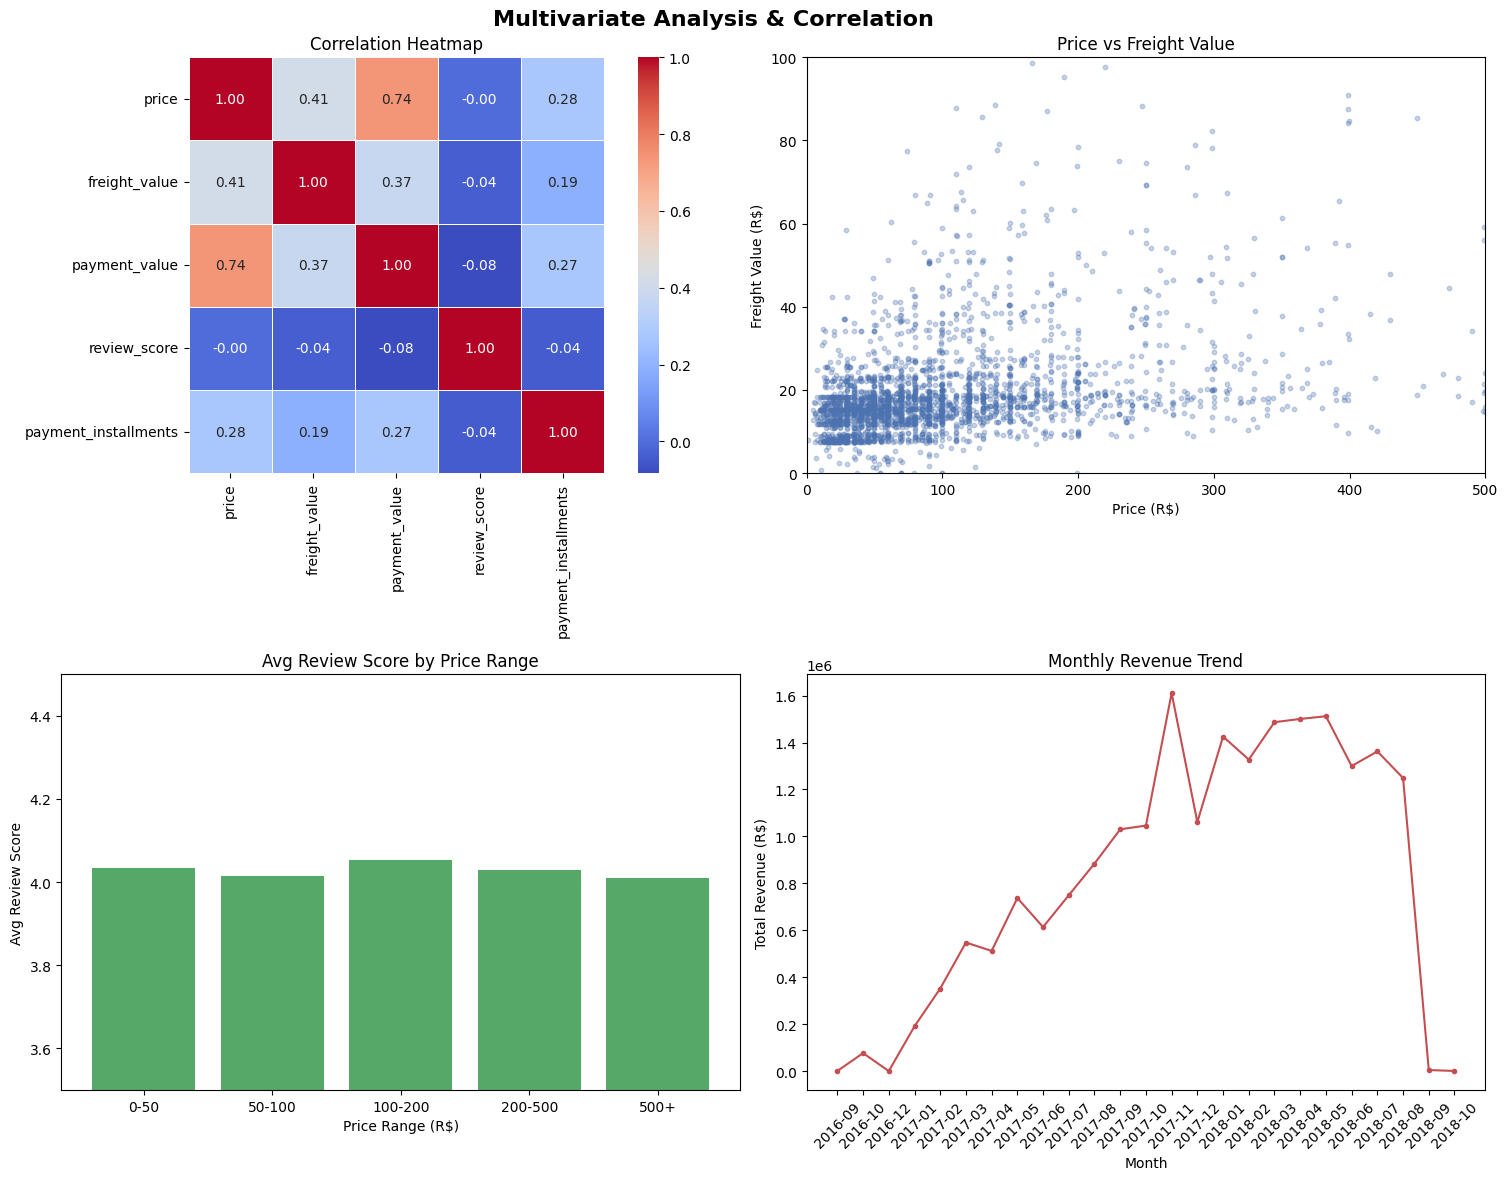

Saved!


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Multivariate Analysis & Correlation", fontsize=16, fontweight="bold")

# 1. Correlation heatmap
corr_cols = ["price", "freight_value", "payment_value", "review_score", "payment_installments"]
corr_matrix = master[corr_cols].dropna().corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            ax=axes[0,0], square=True, linewidths=0.5)
axes[0,0].set_title("Correlation Heatmap")

# 2. Price vs Freight Value scatter
sample = master[["price", "freight_value", "product_category_name_english"]].dropna().sample(3000, random_state=42)
axes[0,1].scatter(sample["price"], sample["freight_value"], alpha=0.3, color="#4C72B0", s=10)
axes[0,1].set_title("Price vs Freight Value")
axes[0,1].set_xlabel("Price (R$)")
axes[0,1].set_ylabel("Freight Value (R$)")
axes[0,1].set_xlim(0, 500)
axes[0,1].set_ylim(0, 100)

# 3. Review score vs payment value boxplot
master["price_bucket"] = pd.cut(master["price"], bins=[0, 50, 100, 200, 500, 10000], 
                                 labels=["0-50", "50-100", "100-200", "200-500", "500+"])
review_by_price = master.groupby("price_bucket", observed=True)["review_score"].mean().reset_index()
axes[1,0].bar(review_by_price["price_bucket"], review_by_price["review_score"], color="#55A868")
axes[1,0].set_title("Avg Review Score by Price Range")
axes[1,0].set_xlabel("Price Range (R$)")
axes[1,0].set_ylabel("Avg Review Score")
axes[1,0].set_ylim(3.5, 4.5)

# 4. Monthly revenue trend
monthly_revenue = master.groupby("order_year_month")["payment_value"].sum().reset_index()
monthly_revenue = monthly_revenue[monthly_revenue["order_year_month"] != "NaT"]
axes[1,1].plot(monthly_revenue["order_year_month"], monthly_revenue["payment_value"], 
               color="#C44E52", marker="o", markersize=3)
axes[1,1].set_title("Monthly Revenue Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Total Revenue (R$)")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/03_multivariate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 5. KPI Dashboard Mock-up
A static dark-themed dashboard summarising the most important business metrics and KPIs derived from the analysis.

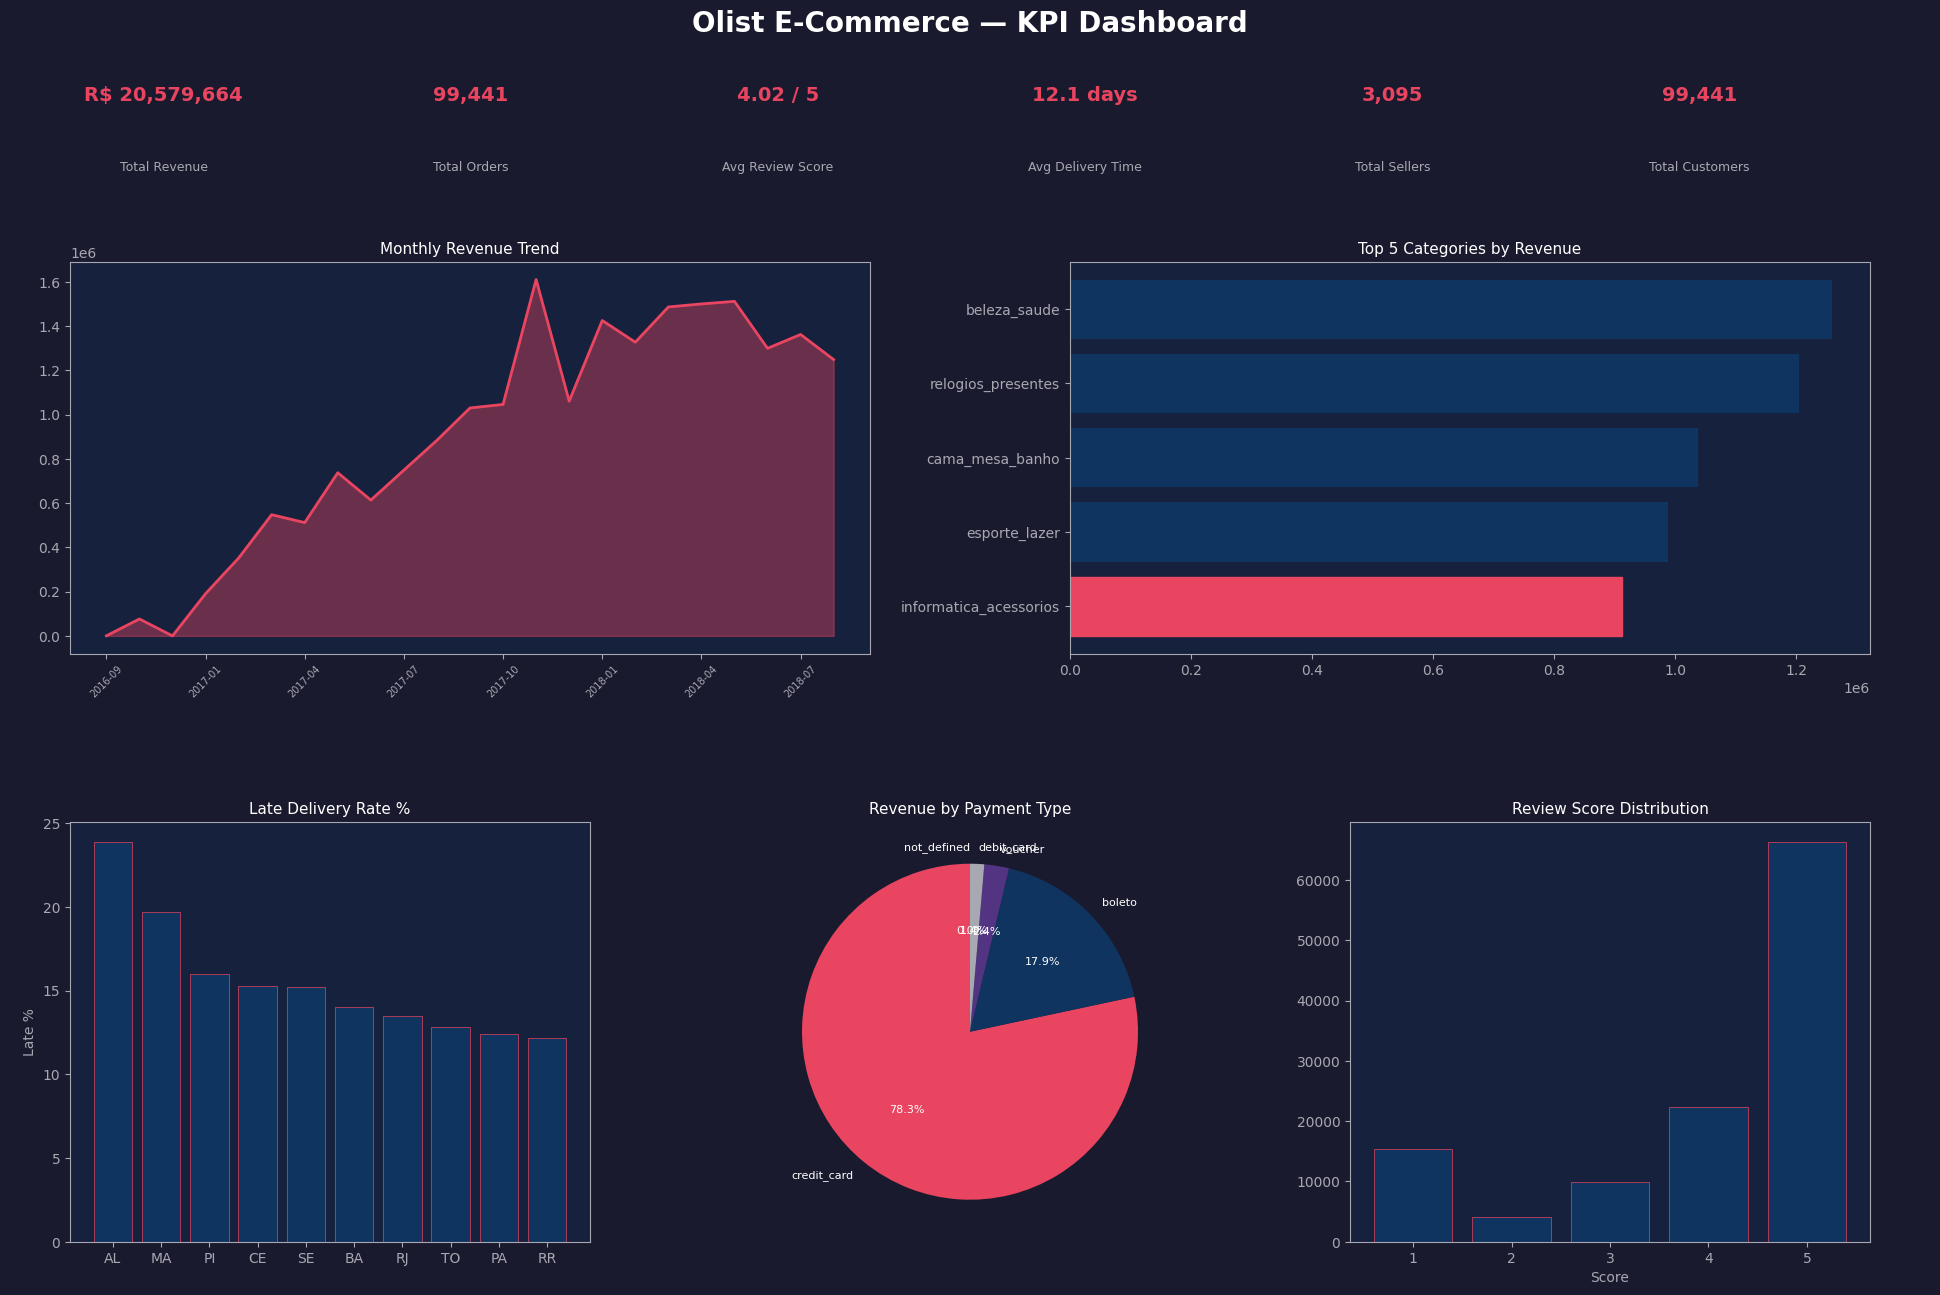

Saved!


In [19]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("Olist E-Commerce — KPI Dashboard", fontsize=20, fontweight="bold", 
             color="white", y=0.98)

# ── KPI Summary Row ─────────────────────────────────────────────────
kpi_ax = fig.add_axes([0.02, 0.85, 0.96, 0.10])
kpi_ax.set_facecolor("#16213e")
kpi_ax.axis("off")

total_revenue = master["payment_value"].sum()
total_orders = orders["order_id"].nunique()
avg_review = master["review_score"].mean()
avg_delivery = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days.mean()

kpis = [
    ("Total Revenue", f"R$ {total_revenue:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Avg Review Score", f"{avg_review:.2f} / 5"),
    ("Avg Delivery Time", f"{avg_delivery:.1f} days"),
    ("Total Sellers", f"{sellers.shape[0]:,}"),
    ("Total Customers", f"{customers.shape[0]:,}"),
]
for i, (label, value) in enumerate(kpis):
    x = 0.08 + i * 0.16
    kpi_ax.text(x, 0.65, value, transform=kpi_ax.transAxes, fontsize=14,
                fontweight="bold", color="#e94560", ha="center")
    kpi_ax.text(x, 0.15, label, transform=kpi_ax.transAxes, fontsize=9,
                color="#a8a8b3", ha="center")

# ── Chart 1: Monthly Revenue ─────────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.52, 0.40, 0.28])
ax1.set_facecolor("#16213e")
monthly = master[master["order_year_month"] < "2018-09"].groupby("order_year_month")["payment_value"].sum()
ax1.fill_between(range(len(monthly)), monthly.values, alpha=0.4, color="#e94560")
ax1.plot(range(len(monthly)), monthly.values, color="#e94560", linewidth=2)
ax1.set_title("Monthly Revenue Trend", color="white", fontsize=11)
ax1.tick_params(colors="#a8a8b3")
ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(list(monthly.index)[::3], rotation=45, fontsize=7, color="#a8a8b3")
for spine in ax1.spines.values():
    spine.set_edgecolor("#a8a8b3")

# ── Chart 2: Top 5 Categories ────────────────────────────────────────
ax2 = fig.add_axes([0.55, 0.52, 0.40, 0.28])
ax2.set_facecolor("#16213e")
top5 = q1.head(5)
bars = ax2.barh(top5["product_category_name"], top5["total_revenue"], color="#0f3460")
bars[-1].set_color("#e94560")
ax2.set_title("Top 5 Categories by Revenue", color="white", fontsize=11)
ax2.tick_params(colors="#a8a8b3")
ax2.invert_yaxis()
for spine in ax2.spines.values():
    spine.set_edgecolor("#a8a8b3")

# ── Chart 3: Late Delivery by State ──────────────────────────────────
ax3 = fig.add_axes([0.05, 0.10, 0.26, 0.30])
ax3.set_facecolor("#16213e")
ax3.bar(q7["customer_state"], q7["late_pct"], color="#0f3460", edgecolor="#e94560", linewidth=0.5)
ax3.set_title("Late Delivery Rate %", color="white", fontsize=11)
ax3.tick_params(colors="#a8a8b3", axis="both")
ax3.set_ylabel("Late %", color="#a8a8b3")
for spine in ax3.spines.values():
    spine.set_edgecolor("#a8a8b3")

# ── Chart 4: Payment Methods ─────────────────────────────────────────
ax4 = fig.add_axes([0.37, 0.10, 0.26, 0.30])
ax4.set_facecolor("#16213e")
colors = ["#e94560", "#0f3460", "#533483", "#a8a8b3", "#16213e"]
wedges, texts, autotexts = ax4.pie(q5["total_revenue"], labels=q5["payment_type"],
                                    autopct="%1.1f%%", colors=colors, startangle=90)
for text in texts + autotexts:
    text.set_color("white")
    text.set_fontsize(8)
ax4.set_title("Revenue by Payment Type", color="white", fontsize=11)

# ── Chart 5: Review Score Distribution ───────────────────────────────
ax5 = fig.add_axes([0.69, 0.10, 0.26, 0.30])
ax5.set_facecolor("#16213e")
review_counts = master["review_score"].value_counts().sort_index()
ax5.bar(review_counts.index, review_counts.values, color="#0f3460", edgecolor="#e94560", linewidth=0.5)
ax5.set_title("Review Score Distribution", color="white", fontsize=11)
ax5.set_xlabel("Score", color="#a8a8b3")
ax5.tick_params(colors="#a8a8b3")
for spine in ax5.spines.values():
    spine.set_edgecolor("#a8a8b3")

plt.savefig("../outputs/04_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#1a1a2e")
plt.show()
print("Saved!")